# Notebook 05: Why Aggregate Statistics Hide Device Failures

In semiconductor manufacturing, reporting a single mean value per process
group is standard practice — but it can actively mislead engineers about
process health. This notebook demonstrates why, using real MoS$_2$
memristor measurements across four electrode widths.

The core principle: Anscombe’s Quartet (1973) showed that four datasets
with identical summary statistics can have completely different distributions.
The same effect appears in this device dataset — electrode width groups
with apparently reasonable means contain fundamentally different device
populations.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

df = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")

def eng_fmt(val):
    if pd.isna(val):
        return "NaN"
    v = abs(val)
    if v >= 1e-3:  return f"{val * 1e3:.2f} mA"
    if v >= 1e-6:  return f"{val * 1e6:.2f} \u03bcA"
    if v >= 1e-9:  return f"{val * 1e9:.2f} nA"
    if v >= 1e-12: return f"{val * 1e12:.2f} pA"
    return         f"{val * 1e15:.2f} fA"

stats_rows = []
for w in [2, 6, 12, 18]:
    g = df.loc[df["electrode"] == w, "i_on_A"].dropna()
    stats_rows.append({
        "Width (\u03bcm)": w,
        "n":        len(g),
        "mean":     eng_fmt(g.mean()),
        "median":   eng_fmt(g.median()),
        "std":      eng_fmt(g.std()),
        "min":      eng_fmt(g.min()),
        "max":      eng_fmt(g.max()),
    })

tbl = pd.DataFrame(stats_rows).set_index("Width (\u03bcm)")
print("Electrode Width Summary Statistics")
print("=" * 72)
print(tbl.to_string())
print()
print(f"All-device mean (n={len(df['i_on_A'].dropna())}): "
      f"{eng_fmt(df['i_on_A'].mean())}")

Electrode Width Summary Statistics
             n     mean    median      std        min       max
Width (μm)                                                     
2            2  2.55 pA   2.55 pA  5.92 fA    2.54 pA   2.55 pA
6           35  2.22 mA   2.74 mA  2.10 mA    1.87 pA  10.02 mA
12          18  5.89 mA   6.33 mA  2.48 mA  785.00 nA   9.36 mA
18          30  9.44 mA  10.05 mA  3.68 mA    2.49 pA  13.60 mA

All-device mean (n=85): 5.49 mA


## The Mean Tells One Story

The mean i_on values suggest a smooth monotonic trend with electrode width.
A naive engineering report would state: “ON-current scales with electrode
width, mean values range from 2.55 pA to 9.44 mA.”

This statement is technically correct and deeply misleading.

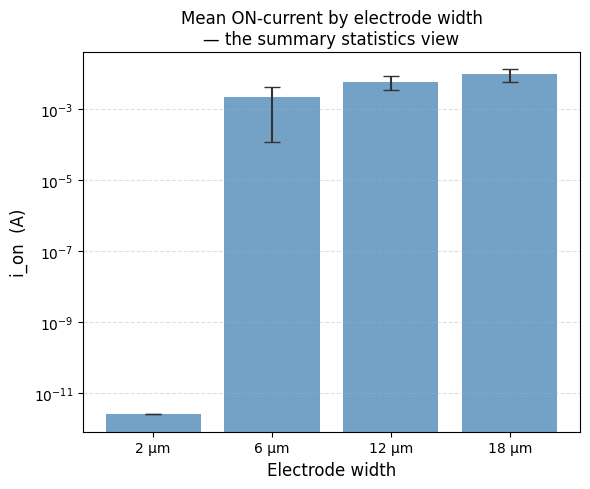

Saved: results/figures/05_mean_bar.png


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

FIG_DIR = PROJ / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")

stats = (
    df.groupby("electrode")["i_on_A"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    stats["electrode"].astype(str) + " \u03bcm",
    stats["mean"],
    yerr=stats["std"],
    capsize=6,
    color="steelblue",
    alpha=0.75,
    error_kw={"elinewidth": 1.5, "ecolor": "#333333"},
)
ax.set_yscale("log")
ax.set_xlabel("Electrode width", fontsize=12)
ax.set_ylabel("i_on  (A)", fontsize=12)
ax.set_title(
    "Mean ON-current by electrode width\n"
    "\u2014 the summary statistics view",
    fontsize=12,
)
ax.grid(True, axis="y", which="both", ls="--", alpha=0.4)
plt.tight_layout()

out = FIG_DIR / "05_mean_bar.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

## The Distribution Tells Another

When we look at the full distribution per electrode group, three distinct
device populations emerge that the mean completely obscures.

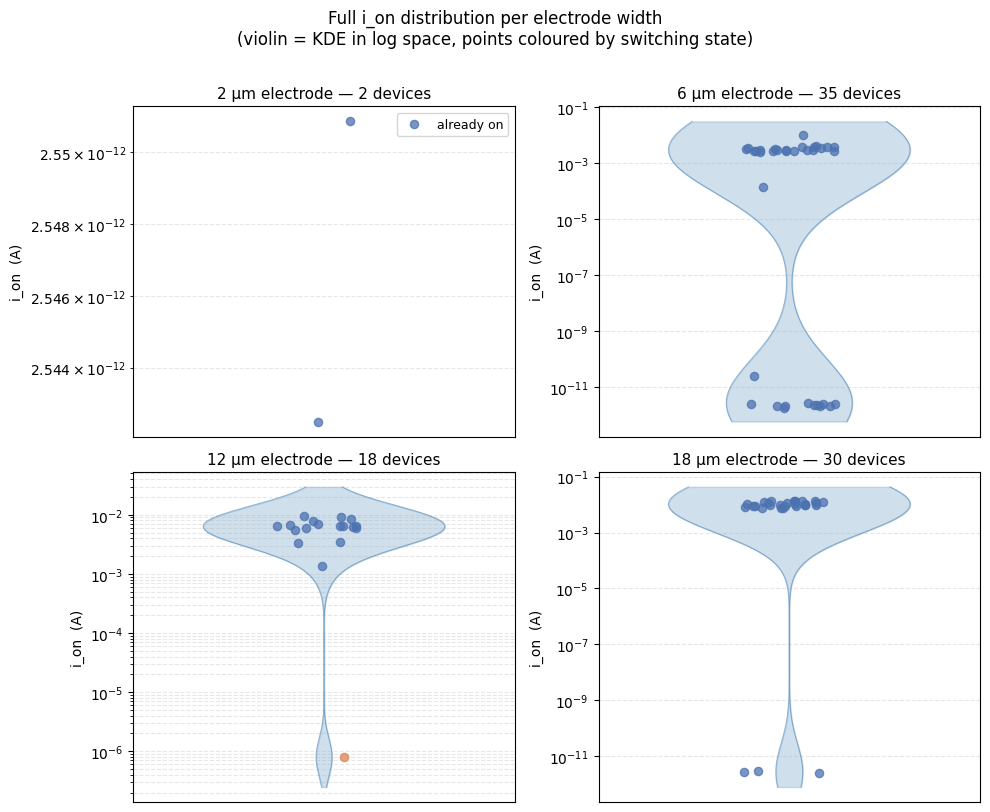

Saved: results/figures/05_distribution_grid.png


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

df = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")

STATE_COLORS = {"already_on": "#4C72B0", "switched": "#DD8452"}
WIDTHS = [2, 6, 12, 18]

rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, w in zip(axes.flat, WIDTHS):
    subset = df[df["electrode"] == w].dropna(subset=["i_on_A"]).copy()
    n      = len(subset)
    vals   = subset["i_on_A"].values
    log_v  = np.log10(vals)

    # Violin via KDE in log space — needs at least 3 distinct values
    unique_log = np.unique(log_v)
    if len(unique_log) >= 3:
        bw = 0.35
        kde = scipy_stats.gaussian_kde(log_v, bw_method=bw)
        y_grid  = np.linspace(log_v.min() - 0.5, log_v.max() + 0.5, 400)
        density = kde(y_grid)
        density = density / density.max() * 0.38       # half-width
        y_lin   = 10 ** y_grid
        ax.fill_betweenx(y_lin, -density, density,
                         alpha=0.25, color="steelblue", zorder=1)
        ax.plot(-density, y_lin, color="steelblue", lw=0.8, alpha=0.5)
        ax.plot( density, y_lin, color="steelblue", lw=0.8, alpha=0.5)

    # Strip plot coloured by switching_state
    for state, colour in STATE_COLORS.items():
        sub = subset[subset["switching_state"] == state]
        if len(sub) == 0:
            continue
        jitter = rng.uniform(-0.15, 0.15, len(sub))
        ax.scatter(jitter, sub["i_on_A"],
                   color=colour, s=35, alpha=0.75, zorder=3,
                   label=state.replace("_", " "))

    ax.set_yscale("log")
    ax.set_xlim(-0.6, 0.6)
    ax.set_xticks([])
    ax.set_title(f"{w} \u03bcm electrode \u2014 {n} devices", fontsize=11)
    ax.set_ylabel("i_on  (A)", fontsize=10)
    ax.grid(True, axis="y", which="both", ls="--", alpha=0.3)

    # Legend only on first panel
    if w == 2:
        ax.legend(fontsize=9, loc="upper right")

fig.suptitle(
    "Full i_on distribution per electrode width\n"
    "(violin = KDE in log space, points coloured by switching state)",
    fontsize=12, y=1.01,
)
plt.tight_layout()

out = PROJ / "results" / "figures" / "05_distribution_grid.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

## Three Device Populations, Not One

The distributions reveal structure that the mean completely hides:

- **18 \u03bcm and 12 \u03bcm:** tight mA-range distributions — consistent
  switching, low variability. These are well-behaved devices.
- **6 \u03bcm: BIMODAL** — approximately 25% of devices sit at pA (leakage
  level) while ~75% reach mA-range ON-state current. The mean of 2.22 mA
  represents neither population accurately. This is a marginal geometry
  where filament formation is inconsistent, not merely slow.
- **2 \u03bcm:** exclusively pA range — not a “low” ON current, a
  fundamentally different physical state (leakage, no switching).
  Averaging these with switching devices corrupts any aggregate metric.

**Key point:** the na\u00efve mean of all 85 devices combined is approximately
5.49 mA — a number that does not represent any real device in the dataset
accurately. The 6 \u03bcm and 2 \u03bcm populations drag the mean downward;
the 18 \u03bcm population inflates it. The aggregate tells you nothing about
device-level behaviour.

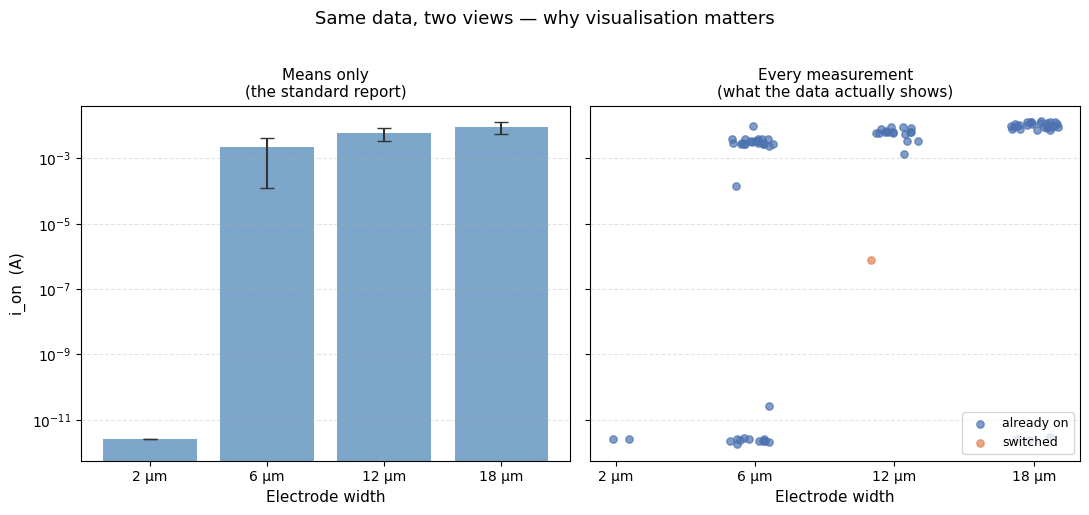

Saved: results/figures/05_mean_vs_distribution.png


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

df = pd.read_csv(PROJ / "data" / "derived" / "memeffect_sweep_aug30_parsed.csv")

STATE_COLORS = {"already_on": "#4C72B0", "switched": "#DD8452"}
widths = [2, 6, 12, 18]

stats = (
    df.groupby("electrode")["i_on_A"]
    .agg(mean="mean", std="std")
    .reindex(widths)
)

# shared y-axis range across both panels
y_min = df["i_on_A"].dropna().min() * 0.3
y_max = df["i_on_A"].dropna().max() * 3.0

fig, (ax_bar, ax_strip) = plt.subplots(1, 2, figsize=(11, 5),
                                        sharey=True)

# ── left: bar chart (misleading view) ────────────────────────────────────────
ax_bar.bar(
    [str(w) + " \u03bcm" for w in widths],
    stats["mean"],
    yerr=stats["std"],
    capsize=5,
    color="steelblue",
    alpha=0.70,
    error_kw={"elinewidth": 1.5, "ecolor": "#333"},
)
ax_bar.set_yscale("log")
ax_bar.set_ylim(y_min, y_max)
ax_bar.set_title("Means only\n(the standard report)", fontsize=11)
ax_bar.set_xlabel("Electrode width", fontsize=11)
ax_bar.set_ylabel("i_on  (A)", fontsize=11)
ax_bar.grid(True, axis="y", which="both", ls="--", alpha=0.35)

# ── right: all individual points (truth) ─────────────────────────────────────
rng = np.random.default_rng(42)
x_positions = {w: i for i, w in enumerate(widths)}

for state, colour in STATE_COLORS.items():
    sub = df[df["switching_state"] == state].dropna(subset=["i_on_A"])
    if len(sub) == 0:
        continue
    x_base  = sub["electrode"].map(x_positions).values.astype(float)
    x_jitter = x_base + rng.uniform(-0.18, 0.18, len(sub))
    ax_strip.scatter(x_jitter, sub["i_on_A"],
                     color=colour, s=28, alpha=0.70, zorder=3,
                     label=state.replace("_", " "))

ax_strip.set_yscale("log")
ax_strip.set_ylim(y_min, y_max)
ax_strip.set_xticks(range(len(widths)))
ax_strip.set_xticklabels([f"{w} \u03bcm" for w in widths])
ax_strip.set_title("Every measurement\n(what the data actually shows)", fontsize=11)
ax_strip.set_xlabel("Electrode width", fontsize=11)
ax_strip.legend(fontsize=9, loc="lower right")
ax_strip.grid(True, axis="y", which="both", ls="--", alpha=0.35)

fig.suptitle("Same data, two views \u2014 why visualisation matters",
             fontsize=13, y=1.02)
plt.tight_layout()

out = PROJ / "results" / "figures" / "05_mean_vs_distribution.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out.relative_to(PROJ)}")

## Connection to Fab Practice

In a production fab this matters at every level:

- **L1 reporting:** if a chamber reports mean thickness, a bimodal
  distribution (some wafers thick, some thin) looks acceptable in the mean
  but signals a process instability.
- **L3 binning:** devices near a performance threshold get misclassified
  if the bin boundary is set from mean statistics rather than the actual
  distribution shape.
- **SPC:** a control chart on the mean will not trigger on a bimodal
  distribution until the problem is severe.

The solution in all cases is the same: plot the distribution, not just the
mean. Notebook 06 builds the drill-down that makes this systematic.

In [5]:
from pathlib import Path

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

MARKER = "## Notebook 05"
ENTRY = (
    "\n---\n"
    "## Notebook 05 \u2014 Why Aggregate Statistics Hide Device Failures\n\n"
    "**Problem:** Aggregate i_on statistics across electrode widths appear to\n"
    "show a smooth monotonic trend. This obscures three fundamentally different\n"
    "device populations.\n\n"
    "**Approach:** Full distribution analysis per electrode width group using\n"
    "violin plots (KDE in log space) and strip plots overlaid. Comparison of\n"
    "mean-only view vs full distribution view.\n\n"
    "**Findings:**\n"
    "- 18 um/12 um: tight mA-range, consistent switching\n"
    "- 6 um: bimodal \u2014 ~25% at pA (leakage), ~75% at mA. Mean of 2.22 mA\n"
    "  represents neither population accurately.\n"
    "- 2 um: exclusively pA (leakage). Not low performance \u2014 a different\n"
    "  physical state entirely.\n"
    "- All-device mean: ~5.49 mA \u2014 represents no real device accurately.\n\n"
    "**Output:** results/figures/05_mean_bar.png,\n"
    "05_distribution_grid.png, 05_mean_vs_distribution.png\n"
)

log_path = PROJ / "docs" / "analysis_log.md"
existing = log_path.read_text(encoding="utf-8") if log_path.exists() else ""
if MARKER not in existing:
    with open(log_path, "a", encoding="utf-8") as f:
        f.write(ENTRY)
    print(f"Appended to {log_path.relative_to(PROJ)}")
else:
    print(f"Skipped (already present): {log_path.relative_to(PROJ)}")

Appended to docs/analysis_log.md


In [6]:
from pathlib import Path

PROJ = Path.cwd()
if not (PROJ / "data").exists():
    PROJ = PROJ.parent

MARKER = "## What I learned \u2014 Notebook 05"
ENTRY = (
    "\n---\n"
    "## What I learned \u2014 Notebook 05\n\n"
    "The 6 um result surprised me most. I expected it to be just \"lower than\n"
    "12 um\" but the distribution shows it is actually two separate populations\n"
    "\u2014 some devices that switched properly and some that never did. The mean\n"
    "hides this completely.\n\n"
    "This is exactly what my mentor meant by Anscombe\'s Quartet applied to fab\n"
    "data. The number looks fine. The plot shows a problem.\n\n"
    "In a real fab, if I reported \"6 um electrode devices have mean i_on of\n"
    "2.22 mA\" to a process engineer, they would make the wrong decision. If I\n"
    "showed them the bimodal distribution, they would immediately ask \"what is\n"
    "different about the devices in the lower population?\" That question leads\n"
    "to a root cause. The mean never gets you there.\n"
)

notes_path = PROJ / "docs" / "personal_notes.md"
existing = notes_path.read_text(encoding="utf-8") if notes_path.exists() else ""
if MARKER not in existing:
    with open(notes_path, "a", encoding="utf-8") as f:
        f.write(ENTRY)
    print(f"Appended to {notes_path.relative_to(PROJ)}")
else:
    print(f"Skipped (already present): {notes_path.relative_to(PROJ)}")

Appended to docs/personal_notes.md
